# Experimentos

Entrenamiento del agente de Q-learning tabular sobre el ambiente `DoorKey` con bola bloqueando la puerta. El agente debe coordinar subtareas (mover la bola, recoger la llave, abrir la puerta, llegar al objetivo) para obtener la recompensa terminal.

El flujo del notebook es:
1. Definir hiperparámetros.
2. Entrenar durante un número de episodios.
3. Guardar la Q-tabla resultante en `../results/`.
4. Evaluar el agente en modo greedy y reportar tasa de éxito y recompensa promedio.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

from env import DoorKeyEnv
from agent import QLearningAgent

c:\Users\aserrano\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Entrenamiento

Cada episodio se corta cuando el entorno marca `terminated`, `truncated`, o al alcanzar `max_steps`. `epsilon` decae geométricamente para pasar de exploración a explotación.

In [2]:
import random

random.seed(42)  # reproducibilidad del agente (el env usa seed=0)

N_EPISODES = 10_000
MAX_STEPS = 576  # mismo límite que el ambiente MiniGrid

env = DoorKeyEnv(seed=0)
agent = QLearningAgent(n_actions=env.n_actions, alpha=0.1, gamma=0.99,
                       epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9995)

rewards_per_episode = []
for ep in range(N_EPISODES):
    state, _ = env.reset()
    total = 0.0
    terminated = False
    for _ in range(MAX_STEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        # Nota: solo `terminated` corta el bootstrap. `truncated` (hit max_steps)
        # no es un estado terminal real, así que debe hacer bootstrap normal.
        agent.update(state, action, reward, next_state, terminated)
        state = next_state
        total += reward
        if terminated or truncated:
            break
    agent.decay_epsilon()
    rewards_per_episode.append(total)
    if (ep + 1) % 500 == 0:
        recent = sum(rewards_per_episode[-500:]) / 500
        print(f'ep {ep+1:5d}  eps={agent.epsilon:.3f}  avg_reward(last500)={recent:+.3f}')

ep   500  eps=0.779  avg_reward(last500)=-0.015
ep  1000  eps=0.606  avg_reward(last500)=-0.090
ep  1500  eps=0.472  avg_reward(last500)=-0.093
ep  2000  eps=0.368  avg_reward(last500)=+0.131
ep  2500  eps=0.286  avg_reward(last500)=+0.333
ep  3000  eps=0.223  avg_reward(last500)=+0.490
ep  3500  eps=0.174  avg_reward(last500)=+1.269
ep  4000  eps=0.135  avg_reward(last500)=+2.461
ep  4500  eps=0.105  avg_reward(last500)=+2.475
ep  5000  eps=0.082  avg_reward(last500)=+2.311
ep  5500  eps=0.064  avg_reward(last500)=+2.632
ep  6000  eps=0.050  avg_reward(last500)=+2.717
ep  6500  eps=0.050  avg_reward(last500)=+2.528
ep  7000  eps=0.050  avg_reward(last500)=+2.588
ep  7500  eps=0.050  avg_reward(last500)=+2.748
ep  8000  eps=0.050  avg_reward(last500)=+2.715
ep  8500  eps=0.050  avg_reward(last500)=+2.689
ep  9000  eps=0.050  avg_reward(last500)=+2.672
ep  9500  eps=0.050  avg_reward(last500)=+2.461
ep 10000  eps=0.050  avg_reward(last500)=+2.568


## Guardar Q-tabla

In [3]:
agent.save('../results/qtable_v2.pkl')
print('Q-tabla guardada. Tamaño (estados visitados):', len(agent.q))

Q-tabla guardada. Tamaño (estados visitados): 635


## Curva de aprendizaje

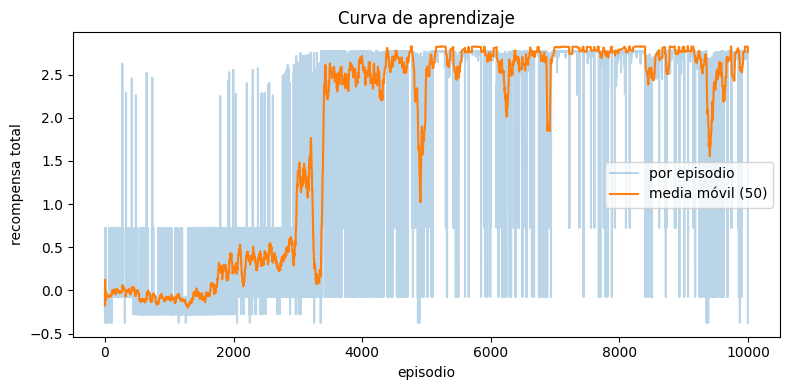

In [4]:
import matplotlib.pyplot as plt

window = 50
smoothed = [sum(rewards_per_episode[max(0, i-window):i+1]) / (min(i+1, window))
            for i in range(len(rewards_per_episode))]

plt.figure(figsize=(8, 4))
plt.plot(rewards_per_episode, alpha=0.3, label='por episodio')
plt.plot(smoothed, label=f'media móvil ({window})')
plt.xlabel('episodio')
plt.ylabel('recompensa total')
plt.title('Curva de aprendizaje')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluación greedy

Cargamos la Q-tabla desde disco y ejecutamos el agente sin exploración para medir su desempeño.

In [5]:
eval_agent = QLearningAgent.load('../results/qtable_v2.pkl')

N_EVAL = 100
successes = 0
eval_rewards = []
for _ in range(N_EVAL):
    state, _ = env.reset()
    total = 0.0
    for _ in range(MAX_STEPS):
        action = eval_agent.greedy_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        total += reward
        if terminated or truncated:
            if terminated and reward > 0:
                successes += 1
            break
    eval_rewards.append(total)

print(f'tasa de éxito: {successes}/{N_EVAL}')
print(f'recompensa promedio: {sum(eval_rewards)/N_EVAL:+.3f}')

tasa de éxito: 100/100
recompensa promedio: +2.776


## Visualización de un episodio

Grabamos cada frame del agente greedy resolviendo el ambiente y generamos un GIF animado.

Episodio terminó en 24 pasos (terminated=True)
GIF guardado en ../video/episode_greedy.gif


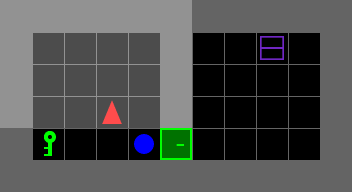

In [6]:
from PIL import Image
from IPython.display import display, Image as IPImage

# Grabar frames de un episodio greedy
vis_agent = QLearningAgent.load('../results/qtable_v2.pkl')
vis_env = DoorKeyEnv(seed=0)
state, _ = vis_env.reset()
frames = [vis_env.render()]

for step in range(MAX_STEPS):
    action = vis_agent.greedy_action(state)
    state, reward, terminated, truncated, _ = vis_env.step(action)
    frames.append(vis_env.render())
    if terminated or truncated:
        break

vis_env.close()
print(f'Episodio terminó en {len(frames)-1} pasos (terminated={terminated})')

# Guardar como GIF
pil_frames = [Image.fromarray(f) for f in frames]
gif_path = '../video/episode_greedy.gif'
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                    duration=200, loop=0)
print(f'GIF guardado en {gif_path}')

# Mostrar en el notebook
display(IPImage(filename=gif_path))